<a href="https://colab.research.google.com/github/rkishorevlr4-26/CodeAlpha_Iris_Flower_Classification/blob/main/CodeAlpha_Iris_Flower_Classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# Import core data analysis and visualization libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import Scikit-learn utilities and models
from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

# Load Iris dataset
iris = load_iris()
df = pd.DataFrame(data=iris.data, columns=iris.feature_names)
df['species'] = pd.Categorical.from_codes(iris.target, iris.target_names)

# Inspect the first five rows
print("Dataset Shape:", df.shape)
df.head()

Dataset Shape: (150, 5)


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


--- Summary Statistics ---
       sepal length (cm)  sepal width (cm)  petal length (cm)  \
count         150.000000        150.000000         150.000000   
mean            5.843333          3.057333           3.758000   
std             0.828066          0.435866           1.765298   
min             4.300000          2.000000           1.000000   
25%             5.100000          2.800000           1.600000   
50%             5.800000          3.000000           4.350000   
75%             6.400000          3.300000           5.100000   
max             7.900000          4.400000           6.900000   

       petal width (cm)  
count        150.000000  
mean           1.199333  
std            0.762238  
min            0.100000  
25%            0.300000  
50%            1.300000  
75%            1.800000  
max            2.500000  

--- Target Distribution ---
species
setosa        50
versicolor    50
virginica     50
Name: count, dtype: int64


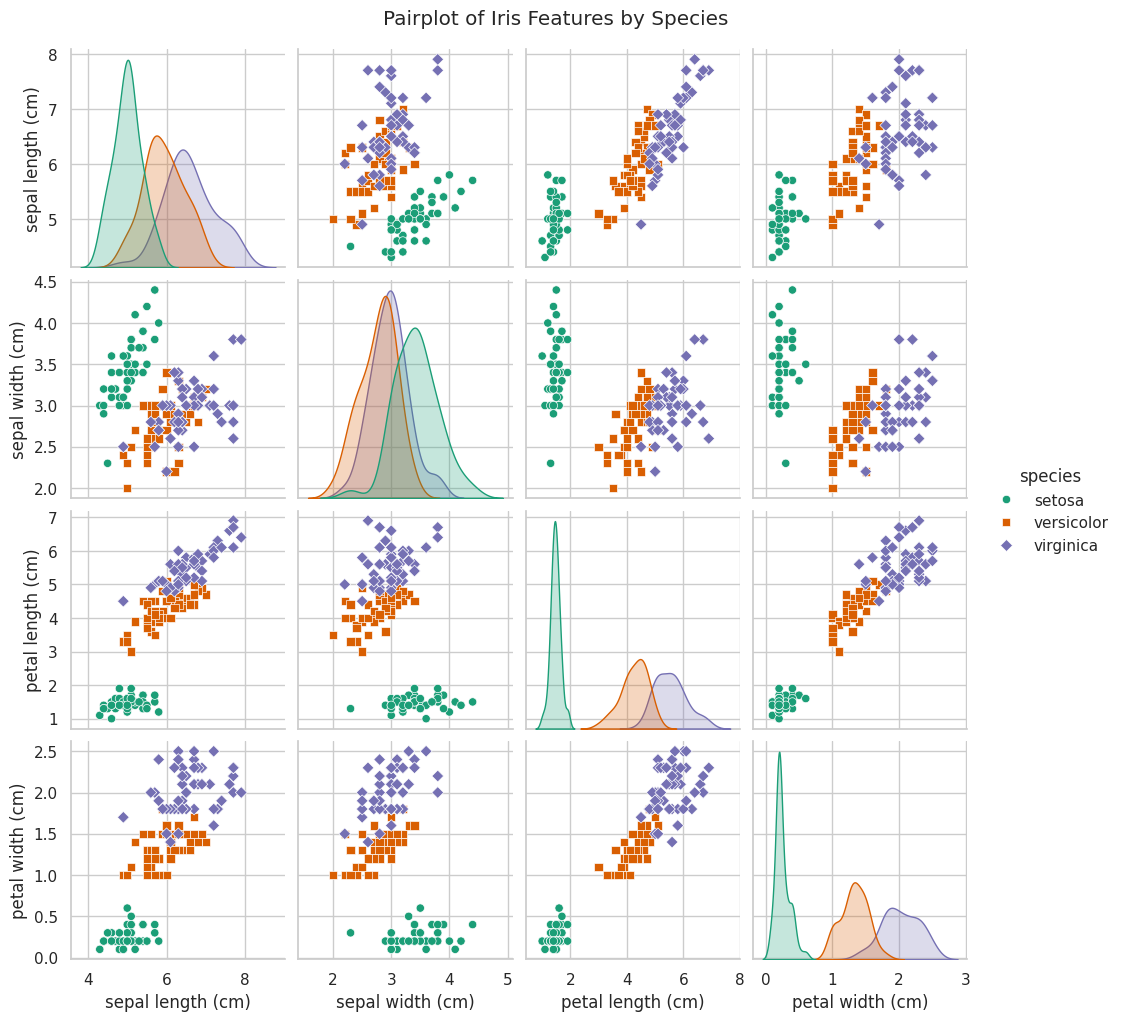

In [2]:
# Summary statistics
print("--- Summary Statistics ---")
print(df.describe())

# Check class distribution
print("\n--- Target Distribution ---")
print(df['species'].value_counts())

# Pairplot to visualize separation between features
sns.set_theme(style="whitegrid")
pair_plot = sns.pairplot(df, hue='species', palette='Dark2', markers=["o", "s", "D"])
pair_plot.fig.suptitle("Pairplot of Iris Features by Species", y=1.02)
plt.show()

In [3]:
# Separate features and target
X = iris.data
y = iris.target

# Split dataset: 80% Training, 20% Testing (stratified to preserve class ratios)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

# Standardize feature scales
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Training samples: {X_train.shape[0]}")
print(f"Testing samples: {X_test.shape[0]}")

Training samples: 120
Testing samples: 30


In [4]:
# Define candidate classifiers
models = {
    "Logistic Regression": LogisticRegression(max_iter=200, random_state=42),
    "Support Vector Machine (SVC)": SVC(kernel='linear', random_state=42),
    "Random Forest": RandomForestClassifier(n_estimators=100, random_state=42)
}

# Train each model and record test accuracy
model_accuracies = {}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    predictions = model.predict(X_test_scaled)
    acc = accuracy_score(y_test, predictions)
    model_accuracies[name] = acc
    print(f"--- {name} ---")
    print(f"Accuracy: {acc * 100:.2f}%\n")
    print("Classification Report:")
    print(classification_report(y_test, predictions, target_names=iris.target_names))
    print("-" * 55)

--- Logistic Regression ---
Accuracy: 93.33%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       0.90      0.90      0.90        10
   virginica       0.90      0.90      0.90        10

    accuracy                           0.93        30
   macro avg       0.93      0.93      0.93        30
weighted avg       0.93      0.93      0.93        30

-------------------------------------------------------
--- Support Vector Machine (SVC) ---
Accuracy: 100.00%

Classification Report:
              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        10
  versicolor       1.00      1.00      1.00        10
   virginica       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30

----------------------------------

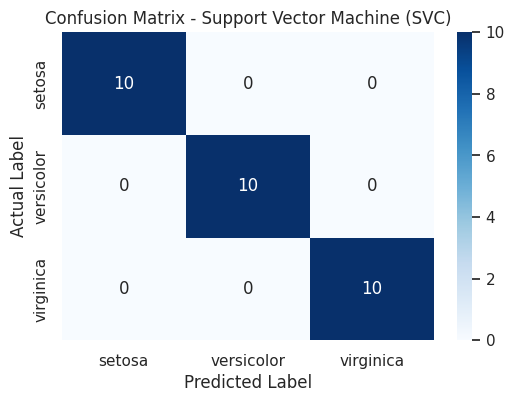

In [5]:
# Evaluate the best-performing model (SVC) with a Confusion Matrix
best_model = models["Support Vector Machine (SVC)"]
y_pred = best_model.predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(6, 4))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=iris.target_names,
    yticklabels=iris.target_names
)
plt.title("Confusion Matrix - Support Vector Machine (SVC)")
plt.xlabel("Predicted Label")
plt.ylabel("Actual Label")
plt.show()

In [6]:
# Predict species for custom flower measurements
# Feature order: [sepal length (cm), sepal width (cm), petal length (cm), petal width (cm)]
sample_flower = np.array([[5.8, 2.7, 5.1, 1.9]])

# Scale the custom input using our fitted StandardScaler
sample_scaled = scaler.transform(sample_flower)

# Predict using the trained SVC model
prediction_idx = best_model.predict(sample_scaled)[0]
predicted_species = iris.target_names[prediction_idx]

print(f"Input Features (cm): {sample_flower[0]}")
print(f"Predicted Iris Species: {predicted_species}")

Input Features (cm): [5.8 2.7 5.1 1.9]
Predicted Iris Species: virginica
